In [16]:
import torch
from sklearn.datasets import make_moons
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

device

'cuda'

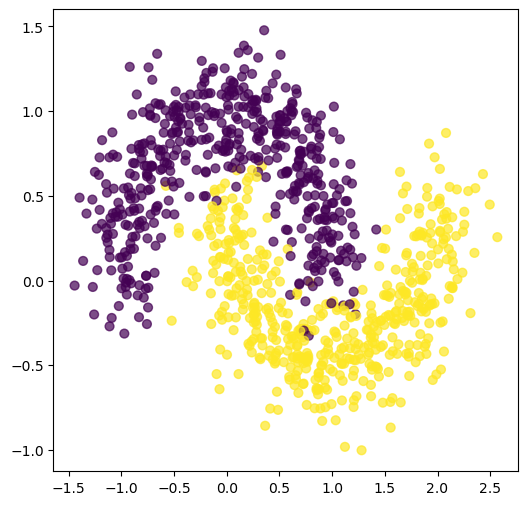

In [17]:
plt.figure(figsize=(6, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    s=40,
    alpha=0.7
)

plt.show()

In [18]:
from torch import nn

class MoonModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # add relu for curves

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

MM = MoonModel()
MM

MoonModel(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [19]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(MM.parameters(), lr=0.1)

In [20]:

# What's coming out of our model?

# logits (raw outputs of model)
y_logits = MM(X_test).squeeze()
print("Logits: ", y_logits[:10])  # first 10 samples

# Prediction probabilities
y_probs = torch.sigmoid(y_logits)
print("Pred probs: ", y_probs[:10])

# Prediction labels
y_labels = torch.round(y_probs)
print("Pred labels: ", y_labels[:10])

Logits:  tensor([ 0.0258,  0.0424, -0.0025,  0.0490, -0.0006,  0.0016,  0.0322,  0.0282,
        -0.0181,  0.0209], grad_fn=<SliceBackward0>)
Pred probs:  tensor([0.5065, 0.5106, 0.4994, 0.5122, 0.4998, 0.5004, 0.5081, 0.5070, 0.4955,
        0.5052], grad_fn=<SliceBackward0>)
Pred labels:  tensor([1., 1., 0., 1., 0., 1., 1., 1., 0., 1.], grad_fn=<SliceBackward0>)


In [21]:
from torchmetrics import Accuracy

## TODO: Uncomment this code to use the Accuracy function
accuracy_fn = Accuracy(task="multiclass", num_classes=2).to(device) # send accuracy function to device
accuracy_fn
     

MulticlassAccuracy()

In [22]:
torch.manual_seed(42)
epochs = 10001

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
MM = MM.to(device)

for epoch in range(epochs):

    MM.train()
    
    #1 forward pass
    y_logits = MM(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # 2 calc loss and acc
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_pred, y_train)

    # 3 optimizer
    optimizer.zero_grad()

    # 4 loss back
    loss.backward()

    # 5 step
    optimizer.step()

    #test
    MM.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = MM(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
        # 2. Calculate loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(test_pred, y_test)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69494, Accuracy: 0.40% | Test Loss: 0.69399, Test Accuracy: 0.50%
Epoch: 100 | Loss: 0.40633, Accuracy: 0.81% | Test Loss: 0.42149, Test Accuracy: 0.77%
Epoch: 200 | Loss: 0.28933, Accuracy: 0.87% | Test Loss: 0.28821, Test Accuracy: 0.86%
Epoch: 300 | Loss: 0.26104, Accuracy: 0.89% | Test Loss: 0.25260, Test Accuracy: 0.88%
Epoch: 400 | Loss: 0.24212, Accuracy: 0.90% | Test Loss: 0.23061, Test Accuracy: 0.89%
Epoch: 500 | Loss: 0.21760, Accuracy: 0.91% | Test Loss: 0.20313, Test Accuracy: 0.90%
Epoch: 600 | Loss: 0.18855, Accuracy: 0.92% | Test Loss: 0.17193, Test Accuracy: 0.93%
Epoch: 700 | Loss: 0.15927, Accuracy: 0.94% | Test Loss: 0.14097, Test Accuracy: 0.94%
Epoch: 800 | Loss: 0.13621, Accuracy: 0.95% | Test Loss: 0.11634, Test Accuracy: 0.97%
Epoch: 900 | Loss: 0.11959, Accuracy: 0.96% | Test Loss: 0.09877, Test Accuracy: 0.98%
Epoch: 1000 | Loss: 0.10828, Accuracy: 0.97% | Test Loss: 0.08651, Test Accuracy: 0.98%
Epoch: 1100 | Loss: 0.10031, Accuracy: 0.97%

In [23]:
import numpy as np

def plot_decision_boundary(model, X, y):
  
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/ 
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), 
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else: 
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary
    
    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

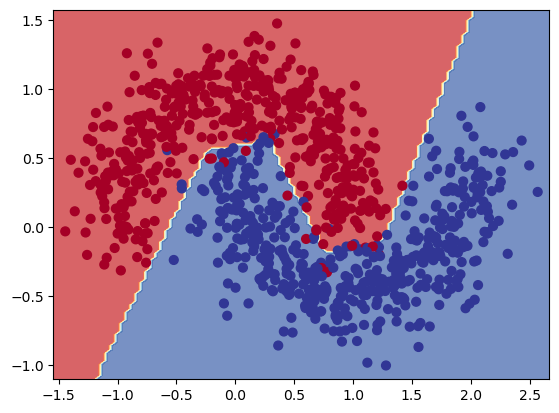

In [24]:
plot_decision_boundary(MM, X, y)

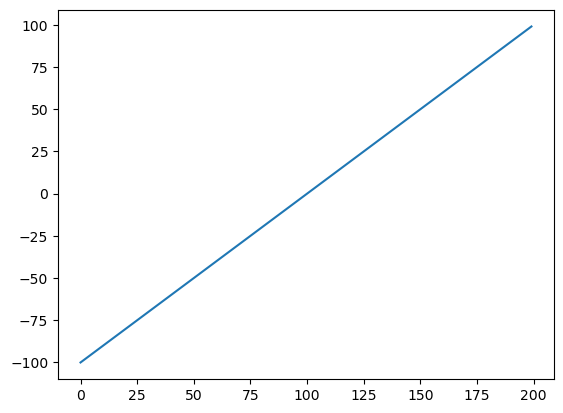

In [25]:
tensor_A = torch.arange(-100, 100, 1)
plt.plot(tensor_A)

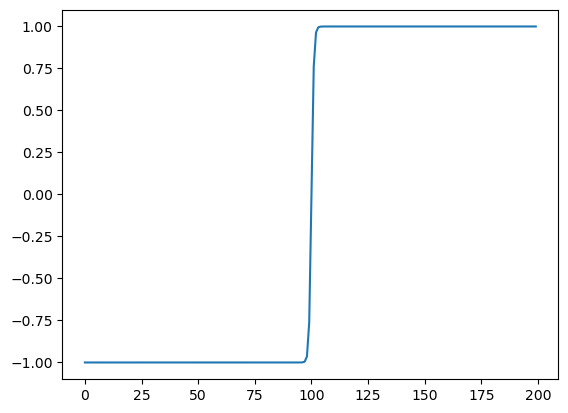

In [26]:
plt.plot(torch.tanh(tensor_A))

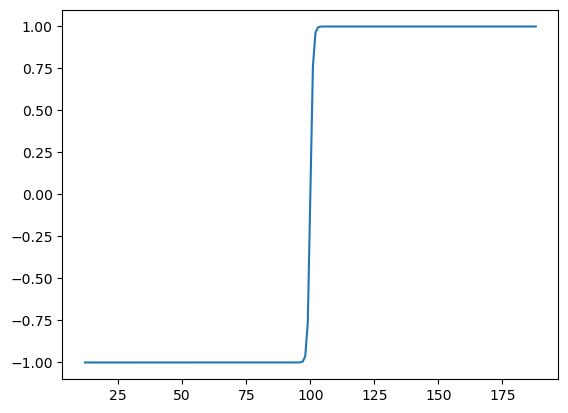

In [27]:
def tanh(x):
  # Source - https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#tanh
  return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

plt.plot(tanh(tensor_A))

In [28]:





#@multiclass





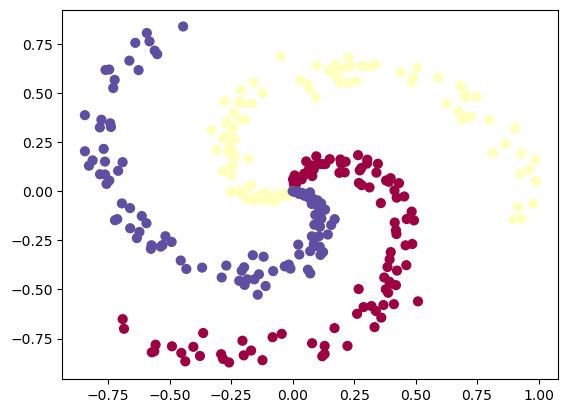

In [37]:
# Code for creating a spiral dataset from CS231n
import numpy as np
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [38]:

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(240, 60, 240, 60)

In [39]:
from torchmetrics import Accuracy
acc_fn = Accuracy(task="multiclass", num_classes=3).to(device) # send accuracy function to device
acc_fn

MulticlassAccuracy()

In [40]:
# Prepare device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

class SpiralModel(nn.Module): 
  def __init__(self):
    super().__init__()
    self.linear1 = nn.Linear(in_features=2, out_features=10)
    self.linear2 = nn.Linear(in_features=10, out_features=10)
    self.linear3 = nn.Linear(in_features=10, out_features=3)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.linear3(self.relu(self.linear2(self.relu(self.linear1(x)))))

model_1 = SpiralModel().to(device)
model_1

SpiralModel(
  (linear1): Linear(in_features=2, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=10, bias=True)
  (linear3): Linear(in_features=10, out_features=3, bias=True)
  (relu): ReLU()
)

In [41]:

# Setup data to be device agnostic
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
print(X_train.dtype, X_test.dtype, y_train.dtype, y_test.dtype)

# Print out untrained model outputs
print("Logits:")
print(model_1(X_train)[:10])

print("Pred probs:")
print(torch.softmax(model_1(X_train)[:10], dim=1))

print("Pred labels:")
print(torch.softmax(model_1(X_train)[:10], dim=1).argmax(dim=1))

torch.float32 torch.float32 torch.int64 torch.int64
Logits:
tensor([[-0.2162, -0.0602,  0.2254],
        [-0.2060, -0.0525,  0.2315],
        [-0.2230, -0.0609,  0.2382],
        [-0.2181, -0.0512,  0.2927],
        [-0.2201, -0.0499,  0.2791],
        [-0.2190, -0.0563,  0.2451],
        [-0.2220, -0.0585,  0.2444],
        [-0.2258, -0.0633,  0.2366],
        [-0.2036, -0.0541,  0.2249],
        [-0.2176, -0.0499,  0.2942]], device='cuda:0',
       grad_fn=<SliceBackward0>)
Pred probs:
tensor([[0.2685, 0.3139, 0.4176],
        [0.2692, 0.3139, 0.4169],
        [0.2658, 0.3126, 0.4216],
        [0.2599, 0.3071, 0.4331],
        [0.2609, 0.3093, 0.4298],
        [0.2654, 0.3123, 0.4222],
        [0.2651, 0.3122, 0.4227],
        [0.2656, 0.3125, 0.4218],
        [0.2705, 0.3142, 0.4153],
        [0.2597, 0.3071, 0.4332]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
Pred labels:
tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], device='cuda:0')


In [42]:
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(),
                             lr=0.02)

In [43]:
# Build a training loop for the model
epochs = 1000

# Loop over data
for epoch in range(epochs):
  ## Training
  model_1.train()
  # 1. forward pass
  y_logits = model_1(X_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  # 2. calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = acc_fn(y_pred, y_train)
  
  # 3. optimizer zero grad
  optimizer.zero_grad()

  # 4. loss backwards
  loss.backward()

  # 5. optimizer step step step
  optimizer.step()

  ## Testing
  model_1.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_1(X_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    # 2. Caculate loss and acc
    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(test_pred, y_test)

  # Print out what's happening
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.2f} Acc: {acc:.2f} | Test loss: {test_loss:.2f} Test acc: {test_acc:.2f}")

Epoch: 0 | Loss: 1.12 Acc: 0.32 | Test loss: 1.10 Test acc: 0.37
Epoch: 100 | Loss: 0.43 Acc: 0.77 | Test loss: 0.56 Test acc: 0.63
Epoch: 200 | Loss: 0.15 Acc: 0.95 | Test loss: 0.12 Test acc: 0.97
Epoch: 300 | Loss: 0.09 Acc: 0.97 | Test loss: 0.07 Test acc: 1.00
Epoch: 400 | Loss: 0.07 Acc: 0.98 | Test loss: 0.04 Test acc: 1.00
Epoch: 500 | Loss: 0.05 Acc: 0.99 | Test loss: 0.01 Test acc: 1.00
Epoch: 600 | Loss: 0.04 Acc: 0.99 | Test loss: 0.01 Test acc: 1.00
Epoch: 700 | Loss: 0.03 Acc: 0.99 | Test loss: 0.01 Test acc: 1.00
Epoch: 800 | Loss: 0.03 Acc: 0.99 | Test loss: 0.01 Test acc: 1.00
Epoch: 900 | Loss: 0.02 Acc: 0.99 | Test loss: 0.03 Test acc: 0.98


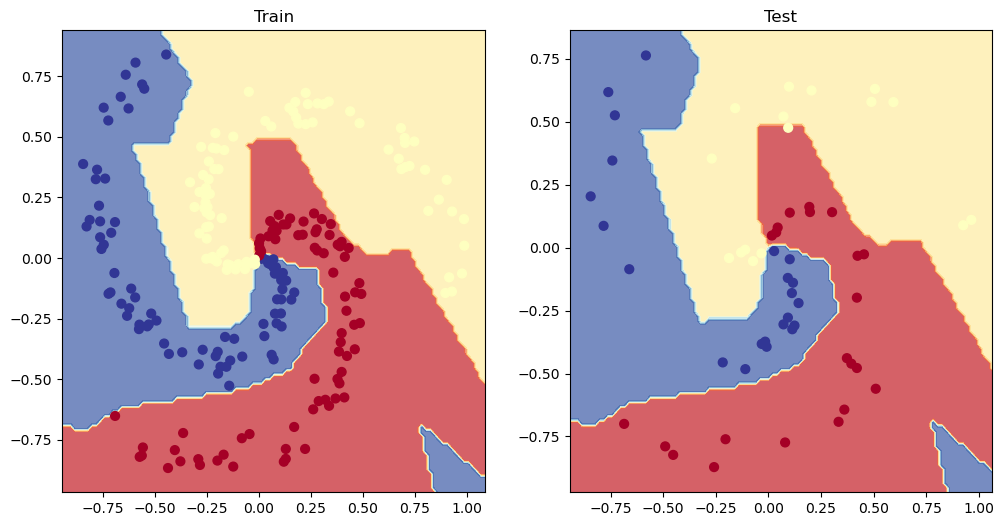

In [44]:

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)